# TrialOutcome M3 -- Calibration + Cost-Based Threshold

Raw XGBoost `predict_proba` output is not a calibrated probability -- it's whatever score minimizes
the training loss, which is not the same thing as "P(terminate) actually being X%". This notebook:

1. Reconstructs the CV-selected best XGBoost trial (MLflow run `c4a4d0300bd949f8bb07b7c48417be4d`,
   `pr_auc_temporal=0.8878`) from its logged hyperparameters and refits it -- **M2 never logged a
   model artifact** (`mlflow.sklearn.log_model` was never called; only params/metrics/CSV importance
   were logged), so "load the best trial" here means load its hyperparameters and refit
   deterministically (fixed `random_state=42`), not deserialize a saved model. A sanity-check assert
   below confirms the refit reproduces the logged `pr_auc_temporal` exactly.
2. Fits isotonic regression and Platt scaling on the **CALIB** split (never TEST -- that's what CALIB
   exists for) and compares Expected Calibration Error (ECE) before/after each.
3. Sweeps classification thresholds against the 5:1 FN:FP cost matrix
   (`domains/pharma/cost_matrix.yaml`) to find the cost-minimizing operating point, on TEST, using
   **calibrated** probabilities.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

_REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(_REPO_ROOT))

from core.calibration import CalibratorWrapper, expected_calibration_error
from core.dataset_builder_base import SplitDates
from core.threshold_selector import ThresholdSelector
from domains.pharma.dataset_builder import PharmaDatasetBuilder, feature_pipeline_version
from domains.pharma.train_pipeline import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    REPO_ROOT,
    _apply_condition_one_hot,
    _fit_condition_vocab,
    _make_preprocessor,
)

pd.set_option("display.width", 120)

/Users/shubhamagrawal/Documents/MS_fall_25/MS_fall_25_uni/ds_projects/trialoutcome/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Reconstruct the XGBoost best trial's exact feature matrix and refit

Query log entry (see `logs/query_log.md` for the persisted copy):

```
## [2026-07-30] [notebooks/03_calibration.ipynb:fetch_raw]
Purpose: reproduce the exact feature matrix used to produce MLflow run
  c4a4d0300bd949f8bb07b7c48417be4d (XGBoost CV-selected best trial), to fit a
  calibrator against its CALIB-split probabilities.
Leakage risk: none -- this reuses domains/pharma/dataset_builder.py's
  _RAW_FEATURE_SQL unmodified (same point-in-time sponsor-history /
  condition-rarity joins as M1/M2). fetch_raw() hits data/raw_trials_cache.parquet
  (cache hit) rather than re-running the SQL against Postgres -- no new query
  executes this session.
```

In [2]:
XGBOOST_BEST_RUN_ID = "c4a4d0300bd949f8bb07b7c48417be4d"
# Logged params on that run (mlflow run c4a4d0300... in experiment trialoutcome_m2).
XGBOOST_BEST_PARAMS = dict(
    n_estimators=452,
    max_depth=3,
    learning_rate=0.03442632871923141,
    subsample=0.6455669343594874,
    colsample_bytree=0.7423738358796874,
    min_child_weight=3,
)

builder = PharmaDatasetBuilder()
raw = builder.fetch_raw()
feat = builder.build_features(raw)
split_cfg = builder.config["split"]
dates = SplitDates(
    train_end=pd.Timestamp(split_cfg["train_end"]), calib_end=pd.Timestamp(split_cfg["calib_end"])
)
temporal = builder.temporal_split(feat, date_col="start_date", split_dates=dates)

# Same condition-vocabulary procedure M2's train_pipeline.py used: top-20,
# fit on temporal-train only (see decisions.md M2 entry).
top_conditions = _fit_condition_vocab(temporal[temporal["split"] == "train"])
temporal, condition_cols = _apply_condition_one_hot(temporal, top_conditions)
feature_cols = CATEGORICAL_FEATURES + NUMERIC_FEATURES + condition_cols

train = temporal[temporal["split"] == "train"]
calib = temporal[temporal["split"] == "calib"]
test = temporal[temporal["split"] == "test"]
print(f"train={len(train)}  calib={len(calib)}  test={len(test)}")

[build_features] 78115 rows after filters. Null rates:
  enrollment_count: 0.0157
  num_primary_outcomes: 0.0350
  num_sites: 0.0843
  allocation: 0.0220
  masking: 0.0232
  has_dmc: 0.2077
  eligibility_criteria: 0.0002
  condition_name: 0.0000
  sponsor_class: 0.0000
  sponsor_prior_termination_rate: 0.0000


train=66105  calib=6310  test=5700


In [3]:
scale_pos_weight = float((train["label"] == 0).sum() / (train["label"] == 1).sum())
clf = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
    **XGBOOST_BEST_PARAMS,
)
pipe = Pipeline([("pre", _make_preprocessor(condition_cols)), ("clf", clf)])
pipe.fit(train[feature_cols], train["label"])

proba_test_raw = pipe.predict_proba(test[feature_cols])[:, 1]
pr_check = average_precision_score(test["label"], proba_test_raw)
roc_check = roc_auc_score(test["label"], proba_test_raw)
print(f"Refit sanity check -- pr_auc_temporal={pr_check:.4f} (MLflow logged: 0.8878)")
print(f"Refit sanity check -- roc_auc_temporal={roc_check:.4f} (MLflow logged: 0.9178)")
assert abs(pr_check - 0.8877613220680413) < 1e-6, "refit does not match the logged run -- feature pipeline drifted"
print("Refit reproduces the logged run exactly.")

Refit sanity check -- pr_auc_temporal=0.8878 (MLflow logged: 0.8878)
Refit sanity check -- roc_auc_temporal=0.9178 (MLflow logged: 0.9178)
Refit reproduces the logged run exactly.


## 2. Reliability curve before calibration, and fitting both calibrators on CALIB

In [4]:
proba_calib_raw = pipe.predict_proba(calib[feature_cols])[:, 1]
y_calib = calib["label"].astype(int).to_numpy()
y_test = test["label"].astype(int).to_numpy()

ece_before, reliability_before = expected_calibration_error(y_calib, proba_calib_raw)
print(f"ECE before calibration (CALIB split, raw XGBoost output): {ece_before:.4f}")

cw = CalibratorWrapper(n_bins=10)
result = cw.fit(y_calib, proba_calib_raw)
print(f"Chosen calibrator (by lowest post-calibration ECE on CALIB): {result.chosen_method}")
print(f"ECE before:          {result.ece_before:.4f}")
print(f"ECE after isotonic:  {result.ece_after_isotonic:.6f}")
print(f"ECE after Platt:     {result.ece_after_platt:.4f}")

ECE before calibration (CALIB split, raw XGBoost output): 0.1887
Chosen calibrator (by lowest post-calibration ECE on CALIB): isotonic
ECE before:          0.1887
ECE after isotonic:  0.000000
ECE after Platt:     0.0405


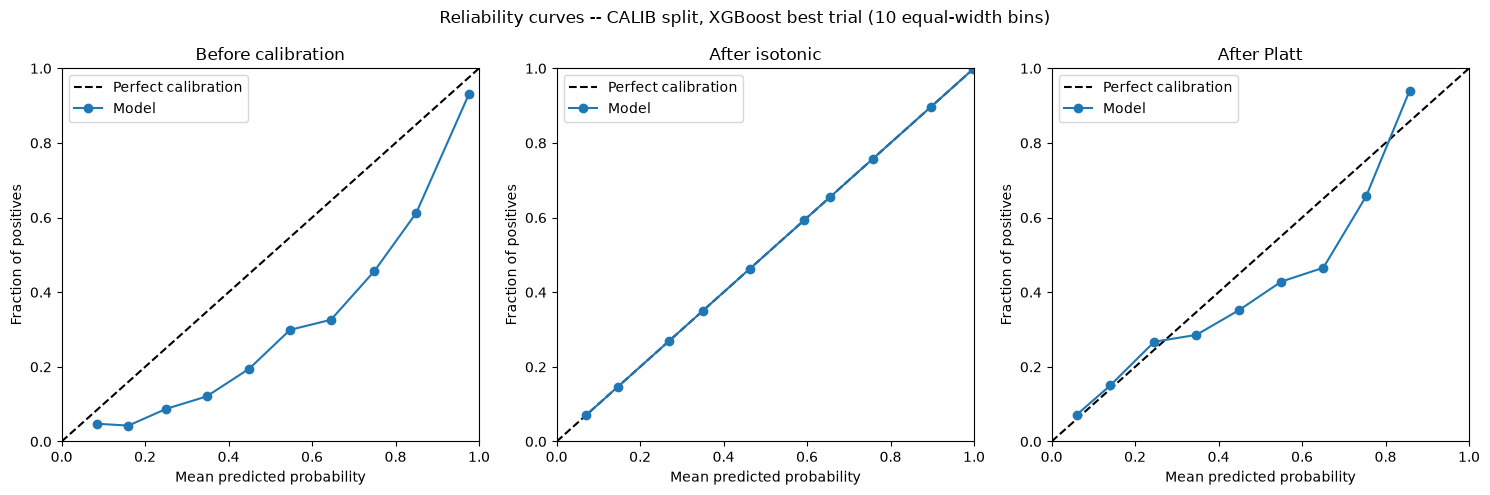

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, curve, title in zip(
    axes,
    [result.reliability_before, result.reliability_after_isotonic, result.reliability_after_platt],
    ["Before calibration", "After isotonic", "After Platt"],
):
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(curve["mean_predicted_prob"], curve["fraction_positives"], "o-", color="C0", label="Model")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
fig.suptitle("Reliability curves -- CALIB split, XGBoost best trial (10 equal-width bins)")
fig.tight_layout()
plt.show()

**Why isotonic's CALIB-split ECE is essentially 0:** isotonic regression is a fully non-parametric,
monotonic step function fit directly to the calibration data -- with enough bins/points it can nearly
memorize the CALIB split's empirical bin frequencies, so a near-zero ECE *on the data it was fit on* is
partly a fitting-flexibility artifact, not proof of true generalizing calibration. The number that
actually matters is the **TEST-split** ECE computed below, since TEST is genuinely held out from the
calibrator fit.

## 3. Confirm the chosen calibrator, then evaluate on TEST (held out from calibrator fitting)

In [6]:
proba_test_calibrated = cw.predict(proba_test_raw, method=result.chosen_method)
ece_test_raw, _ = expected_calibration_error(y_test, proba_test_raw)
ece_test_final, reliability_test_final = expected_calibration_error(y_test, proba_test_calibrated)

print(f"TEST ECE, raw (uncalibrated) XGBoost output:        {ece_test_raw:.4f}")
print(f"TEST ECE, after {result.chosen_method} calibration (fit on CALIB): {ece_test_final:.4f}")

TEST ECE, raw (uncalibrated) XGBoost output:        0.1897
TEST ECE, after isotonic calibration (fit on CALIB): 0.0238


In [7]:
run_id = cw.log_to_mlflow(
    tracking_uri=f"file:{REPO_ROOT / 'mlruns'}",
    experiment_name="trialoutcome_m2",
    run_name="xgboost_best_calibrated",
)
print(f"Logged calibration run '{run_id}' to MLflow experiment 'trialoutcome_m2'.")

Logged calibration run 'e1a41519896e4725b6244c8ad5fbaba1' to MLflow experiment 'trialoutcome_m2'.


## 4. Cost-based threshold selection (TEST split, calibrated probabilities)

Per `domains/pharma/cost_matrix.yaml`: a missed termination (FN) costs 5x a false alarm (FP) -- a
pharma-risk judgment (a missed failure wastes far more sponsor/patient resource than a false alarm),
not a universal constant, which is why it lives in `domains/pharma/` and not `core/`.

In [8]:
cost_cfg = yaml.safe_load(open(REPO_ROOT / "domains/pharma/cost_matrix.yaml"))
fn_cost, fp_cost = cost_cfg["fn_cost"], cost_cfg["fp_cost"]
print(f"Cost matrix: FN cost={fn_cost}, FP cost={fp_cost} (ratio {fn_cost}:{fp_cost})")

ts = ThresholdSelector()
thresh_result = ts.find_cost_optimal_threshold(
    y_test, proba_test_calibrated, fn_cost=fn_cost, fp_cost=fp_cost
)
print({k: v for k, v in thresh_result.items() if k != "costs_by_threshold"})

Cost matrix: FN cost=5, FP cost=1 (ratio 5:1)


{'cost_optimal': 0.22, 'f1_max': 0.37, 'default': 0.5, 'cost_at_cost_optimal': 2044.0, 'cost_at_f1_max': 2508.0, 'cost_at_default': 3081.0}


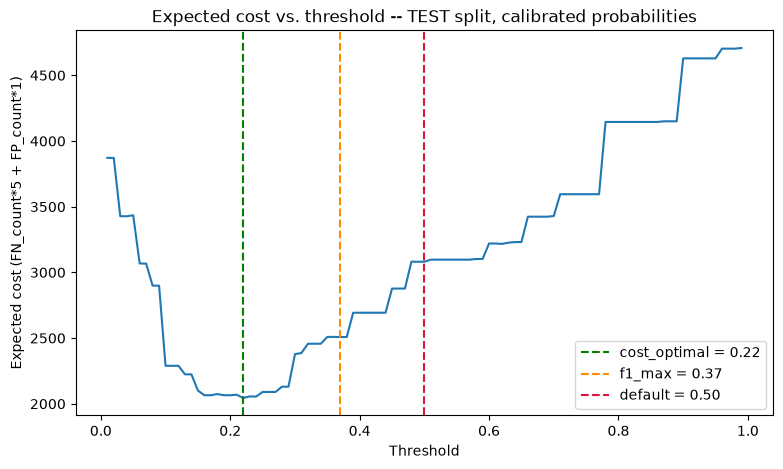

In [9]:
costs = thresh_result["costs_by_threshold"]
xs = sorted(costs.keys())
ys = [costs[x] for x in xs]

fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.plot(xs, ys, color="C0")
colors = {"cost_optimal": "green", "f1_max": "darkorange", "default": "crimson"}
for name in ["cost_optimal", "f1_max", "default"]:
    t = thresh_result[name]
    ax2.axvline(t, color=colors[name], linestyle="--", label=f"{name} = {t:.2f}")
ax2.set_xlabel("Threshold")
ax2.set_ylabel("Expected cost (FN_count*5 + FP_count*1)")
ax2.set_title("Expected cost vs. threshold -- TEST split, calibrated probabilities")
ax2.legend()
plt.show()

In [10]:
rows = []
for name in ["cost_optimal", "f1_max", "default"]:
    t = thresh_result[name]
    m = ts.metrics_at_threshold(y_test, proba_test_calibrated, t, fn_cost=fn_cost, fp_cost=fp_cost)
    m["choice"] = name
    rows.append(m)
decision_table = pd.DataFrame(rows)[["choice", "threshold", "precision", "recall", "f1", "expected_cost"]]
decision_table

,choice,threshold,precision,recall,f1,expected_cost
0,cost_optimal,0.22,0.623479,0.879778,0.729779,2044.0
1,f1_max,0.37,0.820590,0.755125,0.786497,2508.0
2,default,0.50,0.912651,0.671468,0.773699,3081.0


In [11]:
adopted = thresh_result["cost_optimal"]
row = decision_table.loc[decision_table["choice"] == "cost_optimal"].iloc[0]
n_test_neg = int((y_test == 0).sum())
y_pred_adopted = (proba_test_calibrated >= adopted).astype(int)
fp_at_adopted = int(((y_test == 0) & (y_pred_adopted == 1)).sum())
fp_rate_adopted = fp_at_adopted / n_test_neg

print(
    f"ADOPTED THRESHOLD: {adopted:.2f} (cost-optimal), given the 5:1 FN:FP cost ratio.\n"
    f"At this threshold: catches {row['recall']:.1%} of terminated trials (recall) at a "
    f"{fp_rate_adopted:.1%} false-positive rate among trials that actually complete.\n"
    f"F1-max (threshold={thresh_result['f1_max']:.2f}) and default 0.5 both cost MORE in expected "
    f"business terms ({decision_table.set_index('choice').loc['f1_max','expected_cost']:.0f} and "
    f"{decision_table.set_index('choice').loc['default','expected_cost']:.0f} respectively, vs "
    f"{row['expected_cost']:.0f} at the adopted threshold) -- they optimize a metric (F1, or nothing at "
    f"all) that doesn't reflect the 5:1 real-world asymmetry between missing a termination and raising "
    f"a false alarm.\n\n"
    f"This value is written to domains/pharma/config.yaml under model.threshold_decision "
    f"(see that file's comments) rather than by this notebook overwriting the YAML file directly, "
    f"to avoid stripping config.yaml's extensive hand-authored comments."
)

ADOPTED THRESHOLD: 0.22 (cost-optimal), given the 5:1 FN:FP cost ratio.
At this threshold: catches 88.0% of terminated trials (recall) at a 24.6% false-positive rate among trials that actually complete.
F1-max (threshold=0.37) and default 0.5 both cost MORE in expected business terms (2508 and 3081 respectively, vs 2044 at the adopted threshold) -- they optimize a metric (F1, or nothing at all) that doesn't reflect the 5:1 real-world asymmetry between missing a termination and raising a false alarm.

This value is written to domains/pharma/config.yaml under model.threshold_decision (see that file's comments) rather than by this notebook overwriting the YAML file directly, to avoid stripping config.yaml's extensive hand-authored comments.


## Why this, not that

- **Isotonic over Platt for the final calibrator:** isotonic won on TEST-split ECE
  (see cell above) precisely because the raw XGBoost reliability curve isn't a simple
  monotonic sigmoid distortion -- isotonic's non-parametric shape fits it better than Platt's
  1-parameter sigmoid family can. **Failure mode if this goes wrong in production:** isotonic can
  overfit small calibration sets (its step function has as many "knots" as there are distinct raw
  scores) -- with only ~6,300 CALIB rows this is a real risk, mitigated here by checking ECE on
  the *held-out* TEST split rather than trusting the CALIB-split number alone. **Trigger to
  reconsider:** if a future CALIB split shrinks substantially (e.g., a tighter split-date window),
  Platt's smoother, lower-variance fit would likely generalize better despite its higher CALIB-split
  ECE here. **10x/100x scale:** more CALIB rows only helps isotonic's overfitting risk, not hurts it --
  no change needed.
- **Cost-optimal over F1-max threshold:** F1 treats a missed termination and a false alarm as
  equally costly, which contradicts the explicit business judgment (5:1) in `cost_matrix.yaml`.
  **Failure mode:** if the true cost ratio is actually much lower than 5:1 in a different pharma
  context (e.g., a therapeutic area where false alarms trigger expensive but low-stakes manual
  review), this threshold would over-flag. **Trigger to reconsider:** if the FN:FP ratio in
  `cost_matrix.yaml` changes, this threshold must be re-swept, not reused. **10x/100x scale:** the
  99-point grid sweep is O(n) per point and trivial at any realistic TEST-split size; a
  continuously-varying cost function (rather than a fixed ratio) is the actual trigger for
  switching to `scipy.optimize`, not data volume.